In [ ]:
import os, shutil, pathlib

#original_dir = pathlib.Path("../data/kaggle_dogs_vs_cats/train")
#new_base_dir = pathlib.Path("../data/kaggle_dogs_vs_cats_small")


original_dir = pathlib.Path("D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/train/train")
new_base_dir = pathlib.Path("D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/kaggle_dogs_vs_cats_small")

#D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/train/train

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname,
                            dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

## import libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np


import os
import random
import seaborn as sns
from PIL import Image


from keras.models import Sequential, Model, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from keras.applications import VGG16
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

## Data Generators

In [ ]:
train_data_dir = '/content/drive/MyDrive/kaggle_dogs_vs_cats_small/train'
validation_data_dir = '/content/drive/MyDrive/kaggle_dogs_vs_cats_small/validation'
test_data_dir = '/content/drive/MyDrive/kaggle_dogs_vs_cats_small/test'

#train_data_dir = 'D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/small/train'  # Replace with your actual path
#validation_data_dir = 'D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/small/validation'  # Replace with your actual path
#test_data_dir = 'D:/Conestoga/Conestoga_PG_AIML/Winter/2.3 T CSCN 8010 -1 Foundations machine learning framework/GitHub_repository/CSCN8010/Assignments/Lab3_CATS_DOGS/Data/small/test'  # Replace with your actual path

img_width, img_height = 150, 150
batch_size = 32
epochs = 10


train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',

    classes=['cat', 'dog']
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',

    classes=['cat', 'dog']
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,

    classes=['cat', 'dog']
)

Found 2010 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2020 images belonging to 2 classes.


## Define custom model

In [ ]:

def create_custom_cnn():
  model = keras.Sequential([
      keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
      keras.layers.MaxPooling2D((2, 2)),
      keras.layers.Conv2D(64, (3, 3), activation='relu'),
      keras.layers.MaxPooling2D((2, 2)),
      keras.layers.Conv2D(128, (3, 3), activation='relu'),
      keras.layers.MaxPooling2D((2, 2)),
      keras.layers.Flatten(),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(1, activation='sigmoid')
  ])
  return model


checkpoint_cb = keras.callbacks.ModelCheckpoint('best_custom_model.h5', save_best_only=True)



In [ ]:
print("Train generator info:", len(train_generator), train_generator.class_indices)
print("Validation generator info:", len(validation_generator), validation_generator.class_indices)

Train generator info: 63 {'cat': 0, 'dog': 1}
Validation generator info: 32 {'cat': 0, 'dog': 1}


## Train the custom model

In [ ]:
custom_model = create_custom_cnn()
custom_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
custom_model_history = custom_model.fit(train_generator, epochs=epochs, validation_data=validation_generator, callbacks=[checkpoint_cb])

# Load the best custom model
best_custom_model = keras.models.load_model('best_custom_model.h5')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5096 - loss: 0.7896

63/63 ━━━━━━━━━━━━━━━━━━━━ 488s 8s/step - accuracy: 0.5098 - loss: 0.7885 - val_accuracy: 0.5420 - val_loss: 0.6791
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.5747 - loss: 0.6707 - val_accuracy: 0.5950 - val_loss: 0.6959
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6232 - loss: 0.6571

63/63 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.6237 - loss: 0.6566 - val_accuracy: 0.6450 - val_loss: 0.6268
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7113 - loss: 0.5731

63/63 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.7111 - loss: 0.5731 - val_accuracy: 0.6860 - val_loss: 0.5964
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7145 - loss: 0.5608

63/63 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.7143 - loss: 0.5609 - val_accuracy: 0.7140 - val_loss: 0.5481
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.7291 - loss: 0.5324 - val_accuracy: 0.7230 - val_loss: 0.5512
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7527 - loss: 0.4901

63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7527 - loss: 0.4902 - val_accuracy: 0.7280 - val_loss: 0.5420
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7559 - loss: 0.5050

63/63 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.7560 - loss: 0.5049 - val_accuracy: 0.7510 - val_loss: 0.5184
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.7875 - loss: 0.4559 - val_accuracy: 0.6950 - val_loss: 0.5839
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7653 - loss: 0.4612

63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7655 - loss: 0.4612 - val_accuracy: 0.7630 - val_loss: 0.4813


## Fine-tuning VGG16

In [42]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False

vgg_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

## Callbacks for VGG

In [44]:
checkpoint_vgg = keras.callbacks.ModelCheckpoint('best_vgg_model.h5', save_best_only=True)

vgg_model_history = vgg_model.fit(train_generator, epochs=epochs, validation_data=validation_generator, callbacks=[checkpoint_vgg])


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6839 - loss: 0.5951

63/63 ━━━━━━━━━━━━━━━━━━━━ 857s 14s/step - accuracy: 0.6850 - loss: 0.5935 - val_accuracy: 0.8760 - val_loss: 0.3250
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8383 - loss: 0.3585

63/63 ━━━━━━━━━━━━━━━━━━━━ 852s 14s/step - accuracy: 0.8384 - loss: 0.3584 - val_accuracy: 0.8910 - val_loss: 0.2750
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8574 - loss: 0.3169

63/63 ━━━━━━━━━━━━━━━━━━━━ 848s 14s/step - accuracy: 0.8576 - loss: 0.3167 - val_accuracy: 0.8920 - val_loss: 0.2645
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8757 - loss: 0.2918

63/63 ━━━━━━━━━━━━━━━━━━━━ 893s 14s/step - accuracy: 0.8758 - loss: 0.2916 - val_accuracy: 0.9070 - val_loss: 0.2487
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 848s 14s/step - accuracy: 0.8944 - loss: 0.2617 - val_accuracy: 0.8960 - val_loss: 0.2545
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8985 - loss: 0.2414

63/63 ━━━━━━━━━━━━━━━━━━━━ 850s 14s/step - accuracy: 0.8986 - loss: 0.2413 - val_accuracy: 0.9120 - val_loss: 0.2359
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 851s 14s/step - accuracy: 0.9038 - loss: 0.2371 - val_accuracy: 0.8920 - val_loss: 0.2534
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9070 - loss: 0.2165

63/63 ━━━━━━━━━━━━━━━━━━━━ 850s 14s/step - accuracy: 0.9070 - loss: 0.2164 - val_accuracy: 0.9100 - val_loss: 0.2348
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 893s 14s/step - accuracy: 0.9272 - loss: 0.2073 - val_accuracy: 0.8920 - val_loss: 0.2531
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 852s 14s/step - accuracy: 0.9145 - loss: 0.2052 - val_accuracy: 0.9080 - val_loss: 0.2352


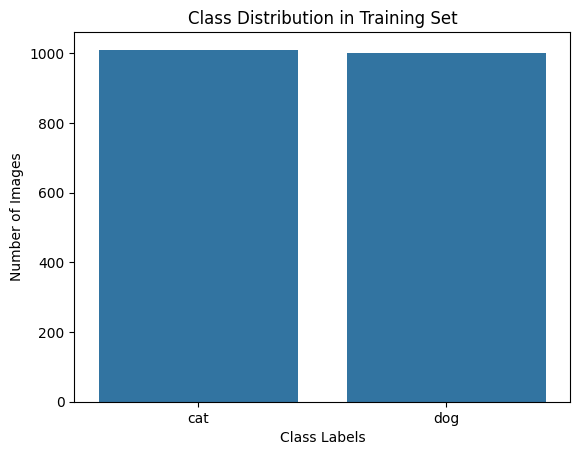

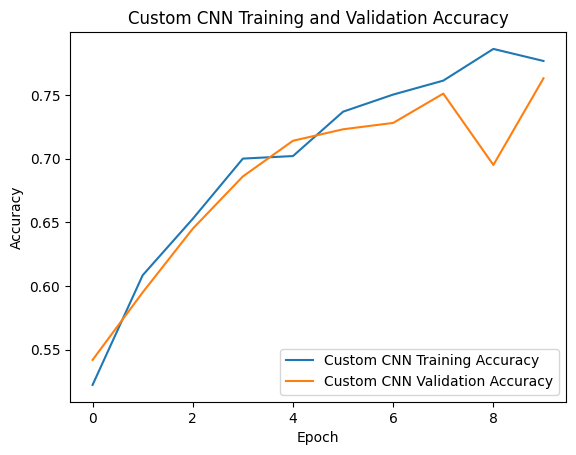

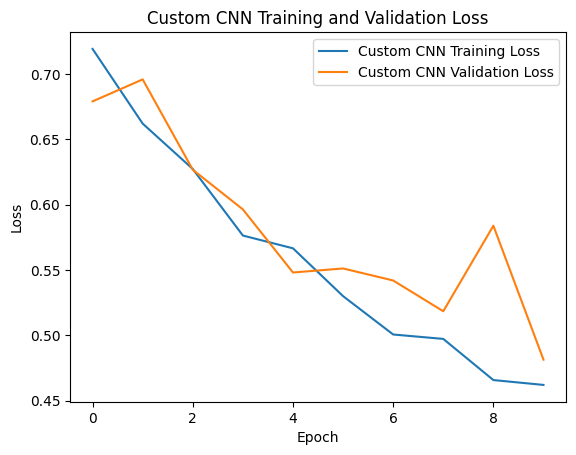

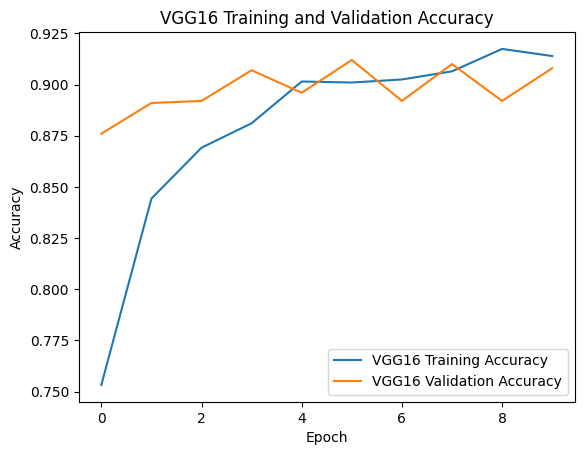

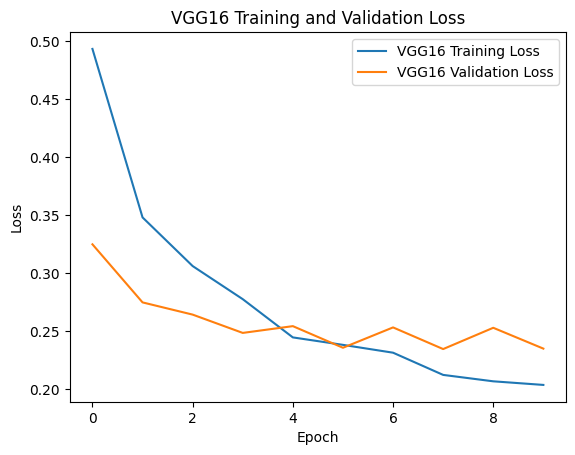

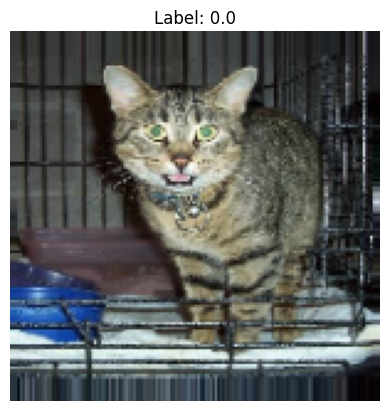

In [45]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming train_generator and validation_generator are defined as in the original code

# Class Distribution
class_counts = train_generator.classes
class_labels = list(train_generator.class_indices.keys())
sns.countplot(x=class_counts)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels)
plt.show()


plt.plot(custom_model_history.history['accuracy'], label='Custom CNN Training Accuracy')
plt.plot(custom_model_history.history['val_accuracy'], label='Custom CNN Validation Accuracy')
plt.title('Custom CNN Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

plt.plot(custom_model_history.history['loss'], label='Custom CNN Training Loss')
plt.plot(custom_model_history.history['val_loss'], label='Custom CNN Validation Loss')
plt.title('Custom CNN Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


plt.plot(vgg_model_history.history['accuracy'], label='VGG16 Training Accuracy')
plt.plot(vgg_model_history.history['val_accuracy'], label='VGG16 Validation Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

plt.plot(vgg_model_history.history['loss'], label='VGG16 Training Loss')
plt.plot(vgg_model_history.history['val_loss'], label='VGG16 Validation Loss')
plt.title('VGG16 Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


images, labels = next(train_generator)

plt.imshow(images[0])
plt.title(f"Label: {labels[0]}")
plt.axis('off')
plt.show()





/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 495s 8s/step - accuracy: 0.7699 - loss: 0.5072
64/64 ━━━━━━━━━━━━━━━━━━━━ 566s 9s/step - accuracy: 0.8906 - loss: 0.2672
Custom Model - Test Accuracy: 0.7525
VGG16 Model - Test Accuracy: 0.8941
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 608ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 565s 9s/step


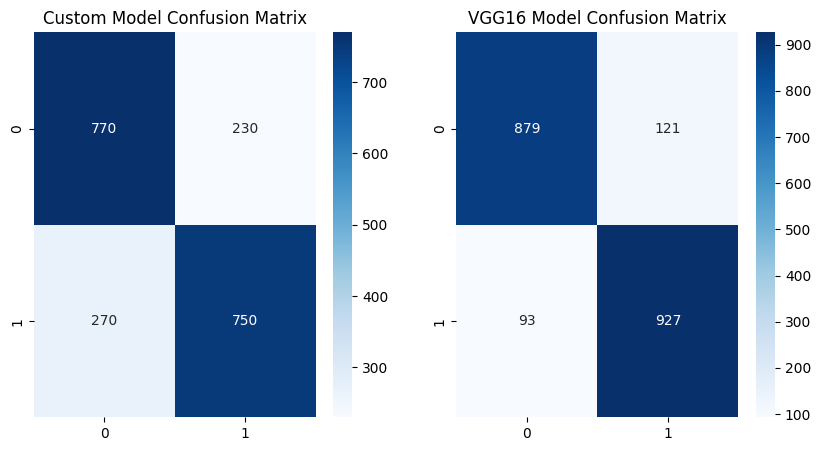

In [46]:
# Load the best models
best_custom_model = keras.models.load_model('best_custom_model.h5')
best_vgg_model = keras.models.load_model('best_vgg_model.h5')

# Evaluate models on the test set
custom_loss, custom_accuracy = best_custom_model.evaluate(test_generator)
vgg_loss, vgg_accuracy = best_vgg_model.evaluate(test_generator)

print(f"Custom Model - Test Accuracy: {custom_accuracy:.4f}")
print(f"VGG16 Model - Test Accuracy: {vgg_accuracy:.4f}")

# Predict on test data
custom_predictions = (best_custom_model.predict(test_generator) > 0.5).astype("int32")
vgg_predictions = (best_vgg_model.predict(test_generator) > 0.5).astype("int32")

# Confusion Matrices
cm_custom = confusion_matrix(test_generator.classes, custom_predictions)
cm_vgg = confusion_matrix(test_generator.classes, vgg_predictions)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues")
plt.title("Custom Model Confusion Matrix")
plt.subplot(1, 2, 2)
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Blues")
plt.title("VGG16 Model Confusion Matrix")
plt.show()


Custom Model Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1000
           1       0.77      0.74      0.75      1020

    accuracy                           0.75      2020
   macro avg       0.75      0.75      0.75      2020
weighted avg       0.75      0.75      0.75      2020

VGG16 Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1000
           1       0.88      0.91      0.90      1020

    accuracy                           0.89      2020
   macro avg       0.89      0.89      0.89      2020
weighted avg       0.89      0.89      0.89      2020

64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 948ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 569s 9s/step


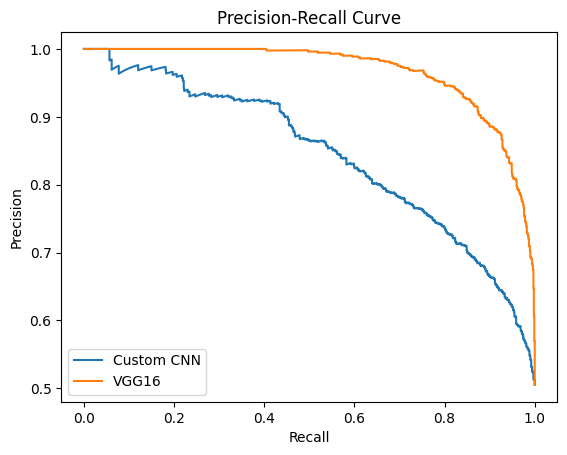

In [47]:

# Classification Reports
print("Custom Model Classification Report:")
print(classification_report(test_generator.classes, custom_predictions))

print("VGG16 Model Classification Report:")
print(classification_report(test_generator.classes, vgg_predictions))

# Precision-Recall Curves
precision_custom, recall_custom, thresholds_custom = precision_recall_curve(test_generator.classes, best_custom_model.predict(test_generator))
precision_vgg, recall_vgg, thresholds_vgg = precision_recall_curve(test_generator.classes, best_vgg_model.predict(test_generator))

plt.plot(recall_custom, precision_custom, label='Custom CNN')
plt.plot(recall_vgg, precision_vgg, label='VGG16')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


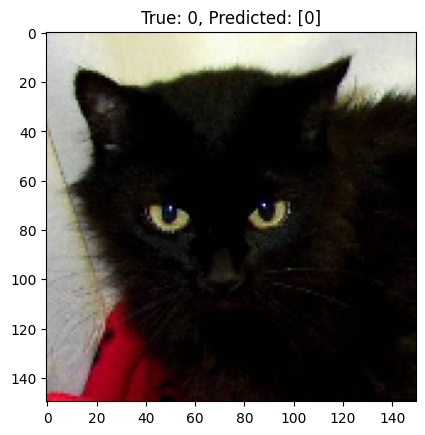

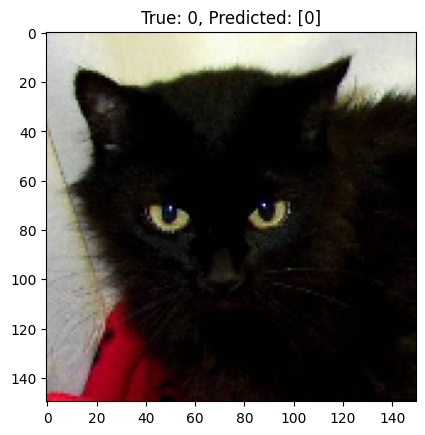

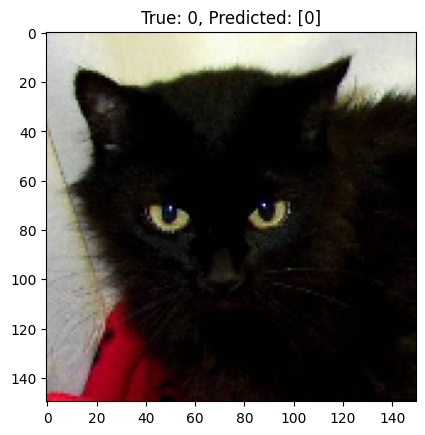

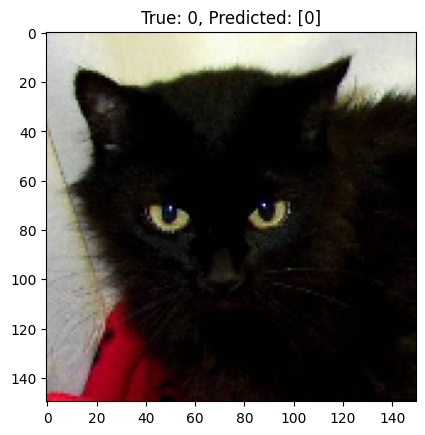

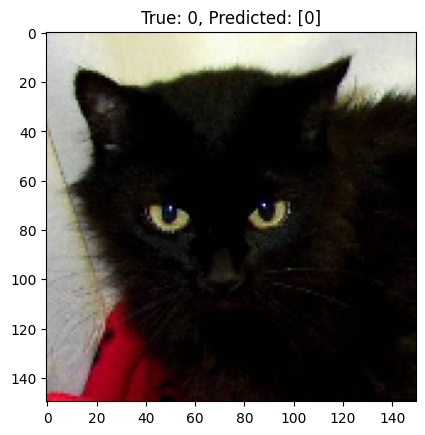

In [48]:


misclassified_indices_custom = np.where(custom_predictions != test_generator.classes)[0]

misclassified_indices_vgg = np.where(vgg_predictions != test_generator.classes)[0]


for i in misclassified_indices_custom[:5]:

    img = test_generator[i // batch_size][0][i % batch_size]
    true_label = test_generator.classes[i]


    plt.imshow(img)
    plt.title(f"True: {true_label}, Predicted: {custom_predictions[i]}")
    plt.show()


In [49]:
# prompt: convert the notebook https://colab.research.google.com/drive/1Ud-e_OpzJuJ_Zuk9jRdbtF8BA1N7VyhK?usp=drive_link into html

# This code converts the provided Jupyter Notebook code into an HTML file.
# Since the original notebook heavily relies on file paths and data that are specific
# to a local environment and Google Drive,  you will need to adapt the file paths
# and data loading mechanisms to match your specific setup.

# Install necessary packages if you haven't already:
# !pip install nbconvert

# Convert the notebook to HTML
!jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/VanillaLabCat_Dogs.ipynb'
# Replace 'your_notebook.ipynb' with the actual file name of your notebook.

# The HTML output will be saved in the same directory as the notebook file.
# You might need to modify the nbconvert command with additional options based on
# your specific requirement.


[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/VanillaLabCat_Dogs.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][13]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stdout',
 'output_type': 'stream',
 'text': 'Epoch 1/10\n'
         '\x1b63/63\x1b '
         '\x1b━━━━━━━━━━━━━━━━━━━━\x1b\x1b\x1b ...'}
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 1771422 bytes to /content/drive/MyDrive/Colab Notebooks/VanillaLabCat_Dogs.html
